<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# Intervalos de confiança
## Prof. Eduardo Pécora

# Intervalos de confiança e n
Tempo estimado: **10** minutos

## Objetivos

Após completar esta aula, você será capaz de:

* Calcular um intervalo de confiança
* Verificar a conexão entre IC e n

,N,Média,Desvio padrão,Erro padrão,Valor crítico t,Margem de erro,Limite inferior,Limite superior
0,5,90.280000,6.000583,2.683542,1.959964,5.259647,85.020353,95.539647
1,10,90.970000,5.008892,1.583951,1.959964,3.104486,87.865514,94.074486
2,15,88.886667,5.809090,1.499901,1.959964,2.939751,85.946916,91.826418
3,20,88.820000,6.088695,1.361474,1.959964,2.668439,86.151561,91.488439
4,30,90.810000,6.274928,1.145640,1.959964,2.245413,88.564587,93.055413
5,50,89.472000,6.078804,0.859673,1.959964,1.684927,87.787073,91.156927
6,100,89.548000,6.367396,0.636740,1.959964,1.247987,88.300013,90.795987


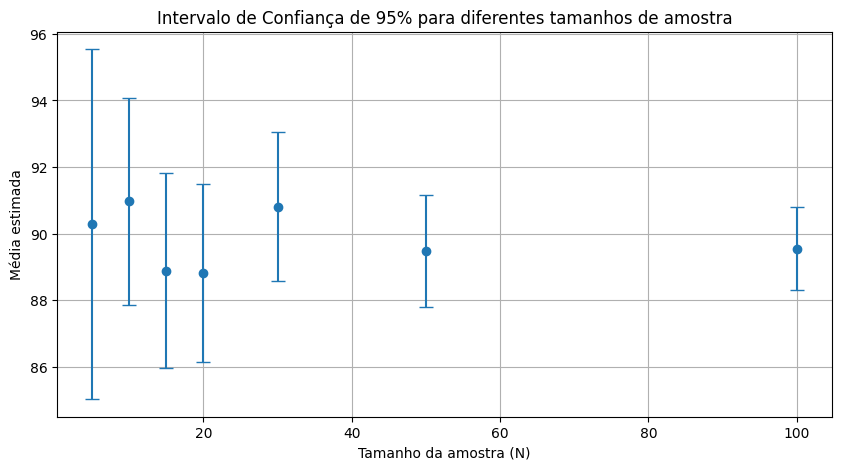

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# ==============================
# 1. Ler a planilha Excel
# ==============================

arquivo = "https://github.com/EduPekUfpr/PythonProject/raw/refs/heads/main/Dados/TxOcupacao.xlsx"        # nome do arquivo
coluna = "Taxa de Ocupacao"       # nome da coluna numérica

df = pd.read_excel(arquivo)

dados = df[coluna].dropna()

# ==============================
# 2. Definir tamanhos de amostra
# ==============================

valores_N = [5, 10, 15, 20, 30, 50, 100]

confianca = 0.95
alpha = 1 - confianca

resultados = []

# ==============================
# 3. Calcular IC para cada N
# ==============================

for N in valores_N:

    # pega uma amostra aleatória de tamanho N
    amostra = dados.sample(n=N, random_state=42)

    media = amostra.mean()
    desvio_padrao = amostra.std(ddof=1)

    erro_padrao = desvio_padrao / np.sqrt(N)

    graus_liberdade = N - 1

    valor_critico = t.ppf(1 - alpha/2, df=graus_liberdade)
    valor_critico = norm.ppf(1 - alpha/2)

    margem_erro = valor_critico * erro_padrao

    limite_inferior = media - margem_erro
    limite_superior = media + margem_erro

    resultados.append({
        "N": N,
        "Média": media,
        "Desvio padrão": desvio_padrao,
        "Erro padrão": erro_padrao,
        "Valor crítico t": valor_critico,
        "Margem de erro": margem_erro,
        "Limite inferior": limite_inferior,
        "Limite superior": limite_superior
    })

# ==============================
# 4. Tabela com os resultados
# ==============================

df_resultados = pd.DataFrame(resultados)

display(df_resultados)

# ==============================
# 5. Gráfico do IC
# ==============================

plt.figure(figsize=(10, 5))

plt.errorbar(
    df_resultados["N"],
    df_resultados["Média"],
    yerr=df_resultados["Margem de erro"],
    fmt="o",
    capsize=5
)

plt.xlabel("Tamanho da amostra (N)")
plt.ylabel("Média estimada")
plt.title("Intervalo de Confiança de 95% para diferentes tamanhos de amostra")
plt.grid(True)
plt.show()

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  

## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>


## Referências:

* Documentação da biblioteca <a href="https://docs.scipy.org/doc/scipy/reference/stats.html">SciPy Stats</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 12-05-2026       | 1.0     | Eduardo Pecora    | Inicial               |


<hr>

&copy; Liga Data Science 2026